Found existing installation: transformers 4.57.5
Uninstalling transformers-4.57.5:
  Successfully uninstalled transformers-4.57.5
Found existing installation: torch 2.9.1
Uninstalling torch-2.9.1:
  Successfully uninstalled torch-2.9.1
  Using cached transformers-4.57.5-py3-none-any.whl.metadata (43 kB)
  Using cached torch-2.9.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
Using cached transformers-4.57.5-py3-none-any.whl (12.0 MB)
Using cached torch-2.9.1-cp312-cp312-manylinux_2_28_x86_64.whl (899.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.0+cu126 requires torch==2.9.0, but you have torch 2.9.1 which is incompatible.
torchvision 0.24.0+cu126 requires torch==2.9.0, but you have torch 2.9.1 which is incompatible.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1: Train 0.0610 | Val 0.0453
Epoch 2: Train 0.0439 | Val 0.0402
Epoch 3: Train 0.0399 | Val 0.0395
Epoch 4: Train 0.0379 | Val 0.0371


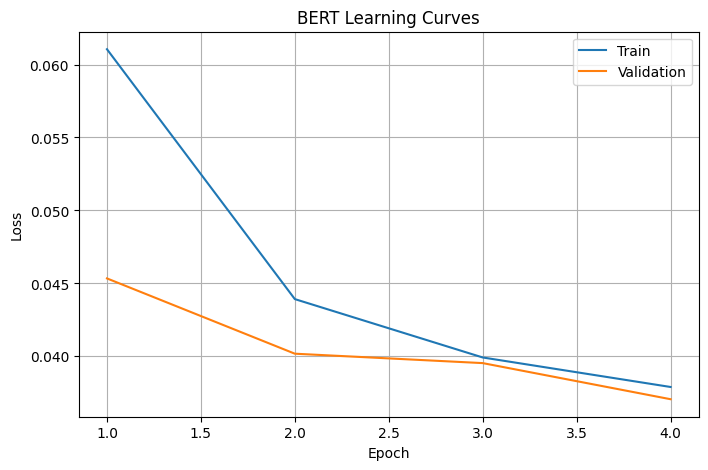


TRAIN REPORT

                 precision    recall  f1-score   support

Defense Evasion       0.89      0.99      0.94     13415
      Discovery       1.00      0.99      0.99    162494
      Execution       0.99      0.99      0.99     65000
       Harmless       0.22      0.52      0.31      1567
         Impact       0.41      0.58      0.48        19
          Other       0.97      0.98      0.98       230
    Persistence       1.00      1.00      1.00    147813

      micro avg       0.99      0.99      0.99    390538
      macro avg       0.78      0.87      0.81    390538
   weighted avg       0.99      0.99      0.99    390538
    samples avg       0.99      0.99      0.99    390538


TEST REPORT

                 precision    recall  f1-score   support

Defense Evasion       0.88      0.99      0.93      2794
      Discovery       1.00      0.99      0.99     34822
      Execution       0.99      0.99      0.99     13900
       Harmless       0.21      0.52      0.30       34

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!pip uninstall -y transformers torch
!pip install transformers torch

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import time, datetime, re, string, base64
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.optim import AdamW


df = pd.read_parquet("../data/ssh_attacks.parquet")

def decode_base64_payload(payload):
    if not isinstance(payload, str):
        return ""
    if "base64" not in payload.lower():
        return payload
    pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    for m in re.findall(pattern, payload):
        try:
            d = base64.b64decode(m).decode("utf-8", errors="ignore")
            if all(c in string.printable for c in d):
                payload = payload.replace(m, d, 1)
        except:
            pass
    return payload

df["decoded_payload"] = df["full_session"].fillna("").astype(str)
df["decoded_payload"] = df["decoded_payload"].apply(decode_base64_payload)

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["Set_Fingerprint"])
sentences = df["decoded_payload"].tolist()

X_temp, X_test, y_temp, y_test = train_test_split(
    sentences, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)  # 0.1765*0.85 ≈ 0.15

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN = 128

def tokenize(texts):
    ids, masks = [], []
    for t in texts:
        enc = tokenizer.encode_plus(
            t,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
        ids.append(enc["input_ids"])
        masks.append(enc["attention_mask"])
    return torch.cat(ids), torch.cat(masks)

X_train_ids, X_train_masks = tokenize(X_train)
X_val_ids, X_val_masks = tokenize(X_val)
X_test_ids, X_test_masks = tokenize(X_test)

y_train = torch.tensor(y_train, dtype=torch.float)
y_val   = torch.tensor(y_val, dtype=torch.float)
y_test  = torch.tensor(y_test, dtype=torch.float)


def make_loader(Xi, Xm, y, shuffle=False):
    ds = TensorDataset(Xi, Xm, y)
    return DataLoader(ds, batch_size=32,
                      sampler=RandomSampler(ds) if shuffle else SequentialSampler(ds))

train_loader = make_loader(X_train_ids, X_train_masks, y_train, shuffle=True)
val_loader   = make_loader(X_val_ids, X_val_masks, y_val)
test_loader  = make_loader(X_test_ids, X_test_masks, y_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert = BertModel.from_pretrained("bert-base-uncased").to(device)

for name, param in bert.named_parameters():
    param.requires_grad = "encoder.layer.11" in name

classifier = nn.Linear(bert.config.hidden_size, y.shape[1]).to(device)

label_counts = y_train.sum(dim=0)
pos_weight = torch.clamp((y_train.shape[0] - label_counts) / label_counts, max=10)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

optimizer = AdamW(
    list(filter(lambda p: p.requires_grad, bert.parameters())) +
    list(classifier.parameters()),
    lr=2e-5
)

epochs = 4
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=len(train_loader)*epochs
)


def evaluate(loader):
    bert.eval()
    classifier.eval()
    y_true, y_pred = [], []
    loss_tot = 0
    with torch.no_grad():
        for ids, masks, labels in loader:
            ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)
            logits = classifier(bert(ids, attention_mask=masks).last_hidden_state[:,0])
            loss = criterion(logits, labels)
            loss_tot += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).int()
            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
    return loss_tot / len(loader), np.vstack(y_true), np.vstack(y_pred)

training_stats = []
total_t0 = time.time()

for epoch in range(epochs):
    bert.train()
    classifier.train()
    train_loss = 0
    for ids, masks, labels in train_loader:
        ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = classifier(bert(ids, attention_mask=masks).last_hidden_state[:,0])
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
    val_loss, _, _ = evaluate(val_loader)
    training_stats.append((epoch+1, train_loss/len(train_loader), val_loss))
    print(f"Epoch {epoch+1}: Train {train_loss/len(train_loader):.4f} | Val {val_loss:.4f}")

df_stats = pd.DataFrame(training_stats, columns=["epoch","train_loss","val_loss"])
plt.figure(figsize=(8,5))
plt.plot(df_stats["epoch"], df_stats["train_loss"], label="Train")
plt.plot(df_stats["epoch"], df_stats["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Learning Curves")
plt.legend()
plt.grid()
plt.show()

_, y_train_true, y_train_pred = evaluate(train_loader)
_, y_test_true, y_test_pred   = evaluate(test_loader)

print("\nTRAIN REPORT\n")
print(classification_report(y_train_true, y_train_pred, target_names=mlb.classes_))

print("\nTEST REPORT\n")
print(classification_report(y_test_true, y_test_pred, target_names=mlb.classes_))

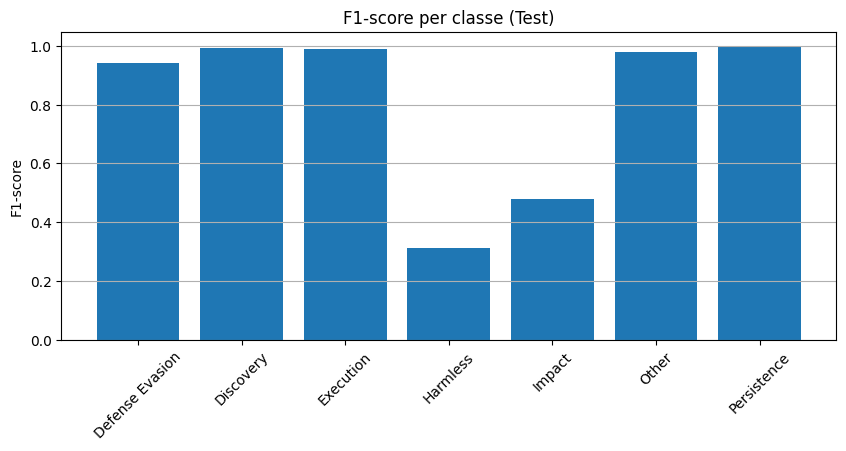

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_true, y_train_pred, average=None)

plt.figure(figsize=(10,4))
plt.bar(mlb.classes_, f1)
plt.xticks(rotation=45)
plt.ylabel("F1-score")
plt.title("F1-score per classe (Test)")
plt.grid(axis="y")
plt.show()


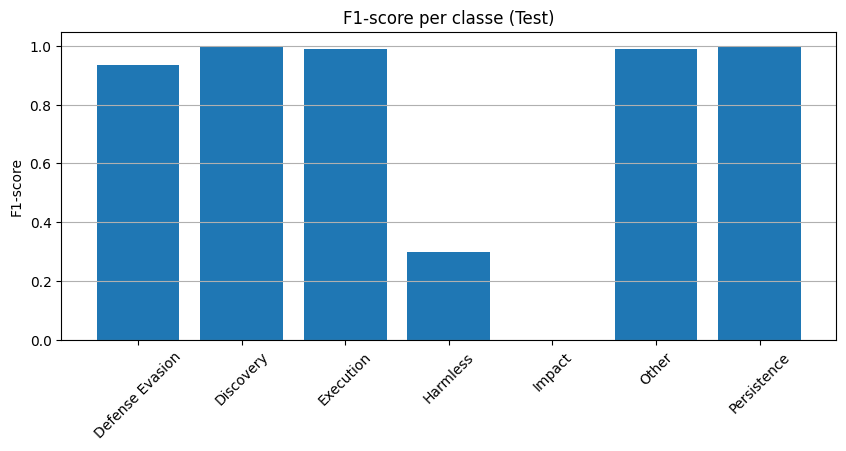

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test_true, y_test_pred, average=None)

plt.figure(figsize=(10,4))
plt.bar(mlb.classes_, f1)
plt.xticks(rotation=45)
plt.ylabel("F1-score")
plt.title("F1-score per classe (Test)")
plt.grid(axis="y")
plt.show()


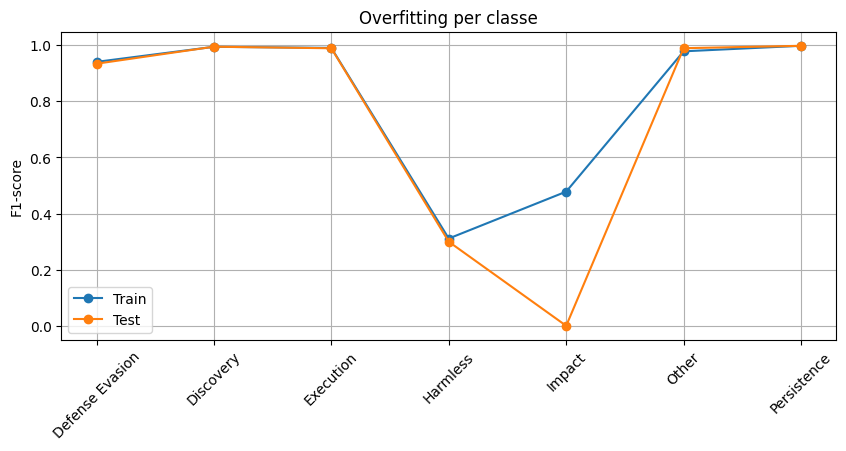

In [ ]:
f1_train = f1_score(y_train_true, y_train_pred, average=None)
f1_test  = f1_score(y_test_true, y_test_pred, average=None)

plt.figure(figsize=(10,4))
plt.plot(mlb.classes_, f1_train, marker="o", label="Train")
plt.plot(mlb.classes_, f1_test, marker="o", label="Test")
plt.xticks(rotation=45)
plt.ylabel("F1-score")
plt.title("Overfitting per classe")
plt.legend()
plt.grid()
plt.show()


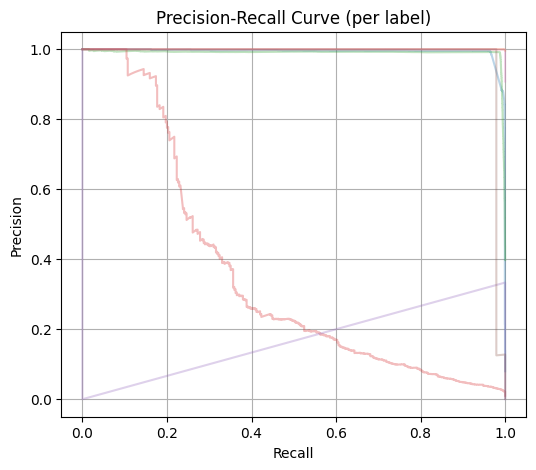

In [ ]:
from sklearn.metrics import precision_recall_curve

bert.eval()
classifier.eval()
probs = []

with torch.no_grad():
    for ids, masks, _ in test_loader:
        ids, masks = ids.to(device), masks.to(device)
        logits = classifier(bert(ids, attention_mask=masks).last_hidden_state[:,0])
        probs.append(torch.sigmoid(logits).cpu().numpy())

y_test_probs = np.vstack(probs)

plt.figure(figsize=(6,5))
for i, label in enumerate(mlb.classes_):
    p, r, _ = precision_recall_curve(y_test_true[:,i], y_test_probs[:,i])
    plt.plot(r, p, alpha=0.3)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (per label)")
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


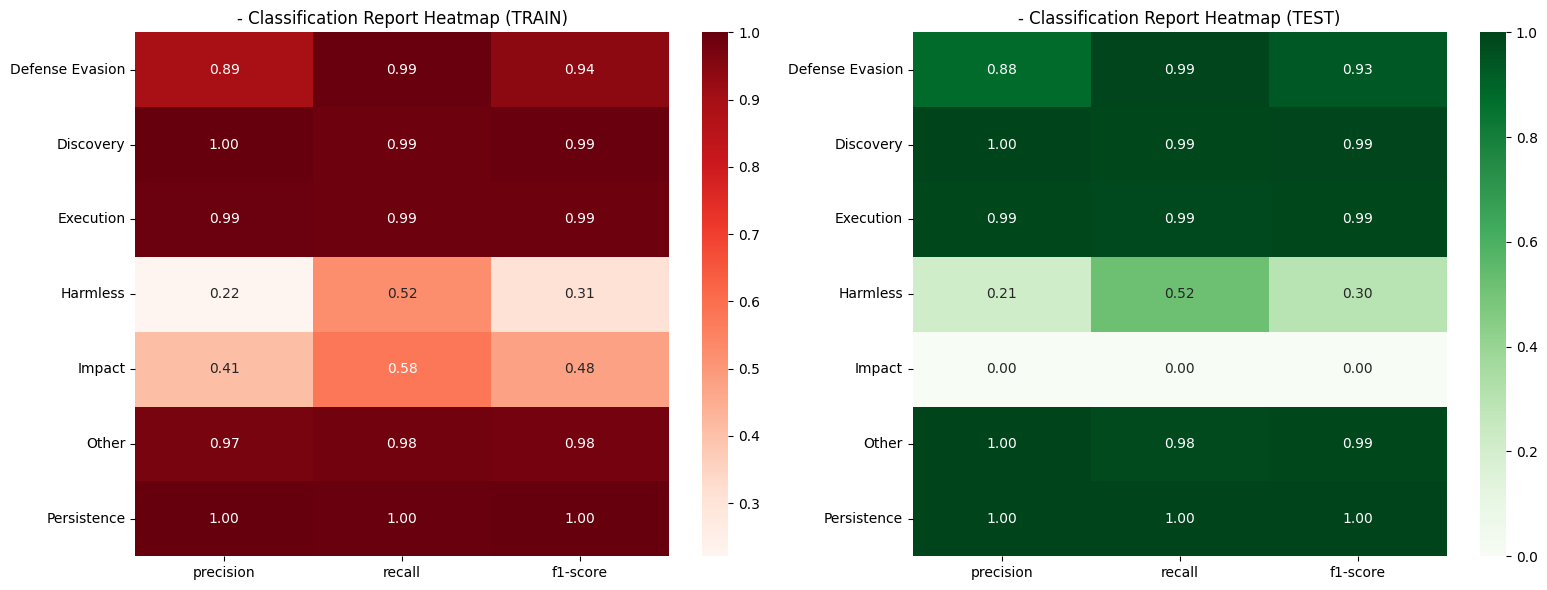

In [ ]:
import seaborn as sns
report_train = classification_report(
    y_train_true, y_train_pred, target_names=mlb.classes_, output_dict=True
)


report_best = classification_report(
    y_test_true, y_test_pred, target_names=mlb.classes_, output_dict=True
)



df_train = pd.DataFrame(report_train).transpose()
df_test = pd.DataFrame(report_best).transpose()

metrics = ["precision", "recall", "f1-score"]

df_train = df_train.loc[mlb.classes_, metrics]
df_test = df_test.loc[mlb.classes_, metrics]



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_train, annot=True, cmap="Reds", fmt=".2f", ax=axes[0])
axes[0].set_title("- Classification Report Heatmap (TRAIN)")

sns.heatmap(df_test, annot=True, cmap="Greens", fmt=".2f", ax=axes[1])
axes[1].set_title("- Classification Report Heatmap (TEST)")

plt.tight_layout()
plt.show()